In [1]:
import numpy as np
import time
#this is calculating the cross_validation
def leave_one_out_cross_validation(data, features, value):
    #Here we are trying to only use the features and value that we need rather than all the data
    filtered_data=[]
    for row in data:
        filtered_row=[]
        for j in range(len(row)):
            #we check to see if it equals the features or value
            if j in features or j==value or j==0:
                #if it does than we append it to filtered row
                filtered_row.append(row[j])
        #we then append filtered row to filtered data
        filtered_data.append(filtered_row)
    #Now comes the algorithm
    number_correctly_classified =0
    #lets set the data to filtered data since thats all we are going to be using
    data = filtered_data
    data_size = len(data)
    # we are looping through the data
    for k in range(data_size):
        #we want to go from the first row to all the way to end
        object_to_classify = data[k][1:]
        #this is the first label
        label_object_to_classify = data[k][0]
        #lets se the distance and location to infinity for now
        nearest_neighbor_distance = float('inf')
        nearest_neighbor_location = float('inf')
        for x in range(data_size):
            #we want to avoid duplicates
            if x!=k:
                #this calculates the distance, k nearest, it takes care of the square, square root and does all the compuations here
                distance = np.linalg.norm(np.array(object_to_classify)-(np.array(data[x][1:])))
                #we want to make sure to take into account the smallest distance we encountered
                if distance < nearest_neighbor_distance:
                    nearest_neighbor_distance = distance
                    #we can also get the location then
                    nearest_neighbor_location = x
                    nearest_neighbor_label = data[nearest_neighbor_location][0]
        #lets check to see if the object we want is the same as the label we got, if so increment the correctly clasified, keeps track of the accuracy
        if label_object_to_classify == nearest_neighbor_label:
            number_correctly_classified = number_correctly_classified + 1
    #then we can divide the number of correctly clasfied by the length of the data
    accuracy = number_correctly_classified / len(data)
    return accuracy

def forward_search_demo(data):
    #this is my timer so that I can calculate how long forward search is taking
    start = time.time()
    num_levels = len(data[0]) #going through the columns, removed the -1
    #going through rows
    num_rows = len(data)
    #Here we are calcuating the class attributes and the total num of instances
    print(f'This dataset has {num_levels-1} (not including the class attribute, with {num_rows} instances')
    total_features=[x for x in range(1,num_levels)] #this is all the features
    current_set_of_features = []
    #calculating accuracy using features, so i can output it in the beg
    total_accuracy = leave_one_out_cross_validation(data, total_features, 0)
    #outputting the total features and how much accuracy that would give
    print(f'Running nearest neighbor with all {num_levels-1} features, using leaving-one-out evaluation, I get an accuracy of {total_accuracy}')
    #now we want to calculate accuracy starting from empty set
    accuracy = leave_one_out_cross_validation(data, current_set_of_features, 0)
    print("Beginning Search")
    # print( f'Uisng features {{ }} with accuracy of {accuracy}')

    max_ac = 0
    max_features = []
   #going through the levels
    for x in range(1,num_levels):
        #going through each feature in the level
        # text = f'On the {x} th level of the search tree'
        # print(text)
        feature_to_add_at_this_level = []
        best_so_far_accuracy = 0
        for k in range(1,num_levels):
            #make sure we dont do duplicates
            if k not in current_set_of_features:   
                #lets calculate the accuracy of each feautre and how much it would be
                accuracy = leave_one_out_cross_validation(data, current_set_of_features, k)   
                text = f'Using feature(s) {{{",".join([str(x) for x in current_set_of_features])},{k}}} accuracy is {accuracy}'
                # print(text)
                #Here we want to find the best accuracy
                if accuracy > best_so_far_accuracy:
                    best_so_far_accuracy = accuracy
                    feature_to_add_at_this_level = k
        #once we find the best accuracy, we can add it to currecnt set of feature, because thats the feature we want to move forward with
        current_set_of_features.append(feature_to_add_at_this_level)
        #This is so we can output the best feature with the highest accuract at the end
        if(best_so_far_accuracy > max_ac):
            max_ac = best_so_far_accuracy
            #getting the features with the highest accuracy
            max_features = [x for x in current_set_of_features]
        text = f'Feature {",".join(str(x) for x in current_set_of_features)} was best, accuracy is {best_so_far_accuracy}'
        # print(text)
    #We are printing out the best features at the end
    print(f'Finished search!! The best feature subset is {max_features}, which has an accuracy of {max_ac}')
    #ending the time and outputting the total time as well
    end = time.time()
    length = end - start
    #print(f'It took, {round(length, 2)} seconds')

def backward_search_demo(data):
    #We are doing the same thing as forward but starting with all features and starting the timer
    start = time.time()
    num_levels = len(data[0]) #going through the columns, removed the -1
    num_rows = len(data)
    #printing out initial information
    print(f'This dataset has {num_levels-1} (not including the class attribute, with {num_rows} instances\n')
    current_set_of_features = [x for x in range(1,num_levels)] #this is all the features
    max_features = current_set_of_features
    accuracy = leave_one_out_cross_validation(data, current_set_of_features, 0)
    #Lets print out the accuracy for all the features
    print(f'Running nearest neighbor with all {num_levels-1} features, using leaving-one-out evaluation, I get an accuracy of {accuracy}\n')
    max_ac = accuracy
    #this is all the features
    # print( f'Uisng features {{{current_set_of_features}}} with accuracy of {accuracy}')

    for l in range(1,num_levels):
        #lets go through all the levels of the tee
        text = f'On the {l} th level of the search tree with accuracy'
        # print(text)
        best = 0
        feature_to_add_at_this_level = []
        # going through all the current set of features
        for f in current_set_of_features:
            new_feature = []
            for x in current_set_of_features:
                #make sure we dont do duplicates
                if(x != f):
                    # we taje a single feature out
                    new_feature.append(x)
            #checking accuracy for the set of features not including one feature
            accuracy = leave_one_out_cross_validation(data, new_feature, 0)
            # print(f'Using feature {{{new_feature}}} with accuracy {accuracy}')
            #we want to find the best accuracy
            if(accuracy > best):
                feature_to_add_at_this_level = new_feature
                best = accuracy
        #and add it to the current set of features
        current_set_of_features = feature_to_add_at_this_level 
        #keep track of the max accuracy and the best feature
        if(best > max_ac):
            max_ac = best
            max_features = [x for x in current_set_of_features]
        #adding the features with the highest accuracy
        text = f'On level {l} i added feature {",".join(str(x) for x in current_set_of_features)} to current set with accuracy {best}'
        # print(text)
    #printing the best feature with the highest accuracy at the end
    print(f'Finished search!! The best feature subset is {max_features}, which has an accuracy of {max_ac}')
    #lets end the time
    end = time.time()
    length = end - start


In [20]:
open_file = open("CS170_Small_DataSet__1.txt")
data = open_file.readlines()
data = [[float(x) for x in row.strip().split("  ")] for row in data]
data = np.array(data)

scaler = StandardScaler()
features = scaler.fit_transform(data[:, 1:])

data = np.hstack((data[:, 0].reshape(-1, 1), features))
data = data.tolist()


In [21]:
forward_search_demo(data)

This dataset has 8 (not including the class attribute, with 700 instances
Running nearest neighbor with all 8 features, using leaving-one-out evaluation, I get an accuracy of 0.83
Beginning Search
Finished search!! The best feature subset is [2, 3], which has an accuracy of 0.9628571428571429


In [22]:
backward_search_demo(data)

This dataset has 8 (not including the class attribute, with 700 instances

Running nearest neighbor with all 8 features, using leaving-one-out evaluation, I get an accuracy of 0.83

Finished search!! The best feature subset is [2, 3], which has an accuracy of 0.9628571428571429


In [23]:
open_file = open("CS170_Large_DataSet__14.txt")
data = open_file.readlines()
data = [[float(x) for x in row.strip().split("  ")] for row in data]
data = np.array(data)

scaler = StandardScaler()
features = scaler.fit_transform(data[:, 1:])

data = np.hstack((data[:, 0].reshape(-1, 1), features))
data = data.tolist()


forward_search_demo(data)

This dataset has 18 (not including the class attribute, with 3000 instances
Running nearest neighbor with all 18 features, using leaving-one-out evaluation, I get an accuracy of 0.7233333333333334
Beginning Search


KeyboardInterrupt: 

Ran in VS Code:

Forward: The best feature subset is [12, 9], which has an accuracy of 0.97

Backward: The best feature subset is [9, 12], which has an accuracy of 0.97

# Task 2

https://archive.ics.uci.edu/dataset/109/wine

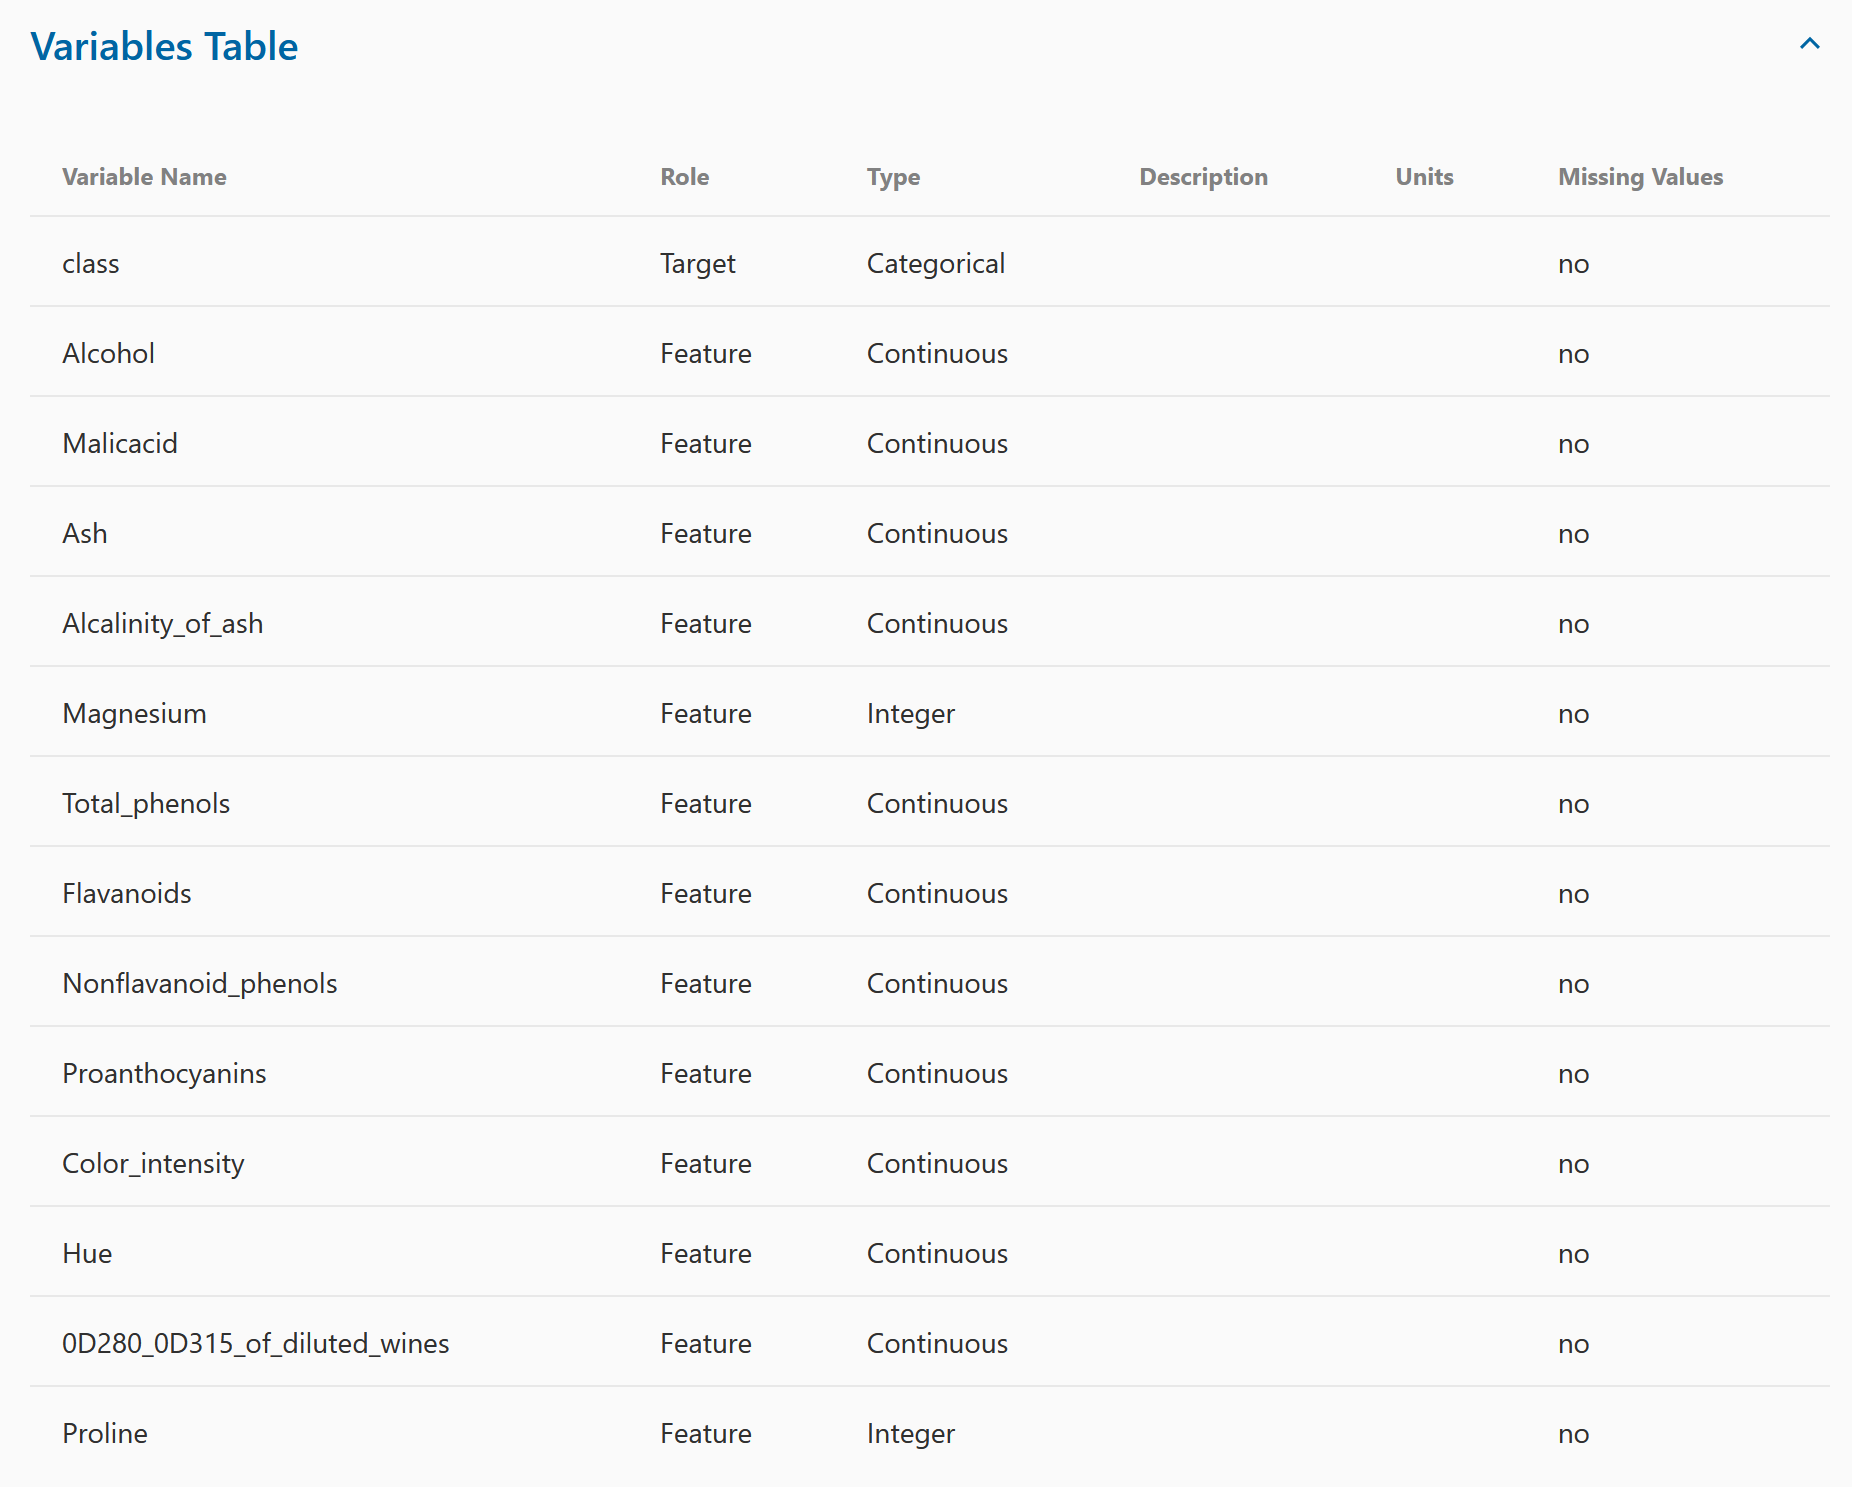

In [2]:
with open(r"C:\Users\Msi\Documents\0 UCR\CS205\wine\wine.names", "r") as file:
    text = file.read()

print(text)

1. Title of Database: Wine recognition data
	Updated Sept 21, 1998 by C.Blake : Added attribute information

2. Sources:
   (a) Forina, M. et al, PARVUS - An Extendible Package for Data
       Exploration, Classification and Correlation. Institute of Pharmaceutical
       and Food Analysis and Technologies, Via Brigata Salerno, 
       16147 Genoa, Italy.

   (b) Stefan Aeberhard, email: stefan@coral.cs.jcu.edu.au
   (c) July 1991
3. Past Usage:

   (1)
   S. Aeberhard, D. Coomans and O. de Vel,
   Comparison of Classifiers in High Dimensional Settings,
   Tech. Rep. no. 92-02, (1992), Dept. of Computer Science and Dept. of
   Mathematics and Statistics, James Cook University of North Queensland.
   (Also submitted to Technometrics).

   The data was used with many others for comparing various 
   classifiers. The classes are separable, though only RDA 
   has achieved 100% correct classification.
   (RDA : 100%, QDA 99.4%, LDA 98.9%, 1NN 96.1% (z-transformed data))
   (All results usi

1st col - class id, then features.

All features are continious, there're no missing values. 

In [3]:
data = np.loadtxt(r"C:\Users\Msi\Documents\0 UCR\CS205\wine\wine.data", delimiter=",")

In [5]:
data

array([[1.000e+00, 1.423e+01, 1.710e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.000e+00, 1.320e+01, 1.780e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.000e+00, 1.316e+01, 2.360e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [3.000e+00, 1.327e+01, 4.280e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [3.000e+00, 1.317e+01, 2.590e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [3.000e+00, 1.413e+01, 4.100e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [6]:
np.unique(data, axis=0).shape[0]

178

In [7]:
np.unique(data[:, 1:], axis=0).shape[0]

178

No duplicates.

In [8]:
data[:, 0]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3.])

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = scaler.fit_transform(data[:, 1:])

data = np.hstack((data[:, 0].reshape(-1, 1), features))

In [26]:
forward_search_demo(data)

# 

This dataset has 13 (not including the class attribute, with 178 instances
Running nearest neighbor with all 13 features, using leaving-one-out evaluation, I get an accuracy of 0.9550561797752809
Beginning Search
Finished search!! The best feature subset is [7, 10, 13, 11, 1, 5, 2, 12], which has an accuracy of 0.9887640449438202


In [29]:
backward_search_demo(data)

This dataset has 13 (not including the class attribute, with 178 instances

Running nearest neighbor with all 13 features, using leaving-one-out evaluation, I get an accuracy of 0.9550561797752809

Finished search!! The best feature subset is [1, 2, 4, 7, 8, 9, 10, 12, 13], which has an accuracy of 0.9831460674157303


In [30]:
print("Forward accuracy: ", leave_one_out_cross_validation(data, [7, 10, 13, 11, 1, 5, 2, 12], 0))
print("Backward accuracy: ", leave_one_out_cross_validation(data, [1, 2, 4, 7, 8, 9, 10, 12, 13], 0))

Forward accuracy:  0.9887640449438202
Backward accuracy:  0.9831460674157303


In [10]:
forward_features = [7, 10, 13, 11, 1, 5, 2, 12]
backward_features = [1, 2, 4, 7, 8, 9, 10, 12, 13]

intersect_features = sorted(list(set(forward_features) & set(backward_features)))

In [12]:
intersect_features

[1, 2, 7, 10, 12, 13]

In [11]:
leave_one_out_cross_validation(data, intersect_features, 0)

0.9550561797752809